In [2]:
# pandas и numpy — основа для работы с данными
# matplotlib и seaborn — для визуализации
# scipy — для статистических тестов
# warnings отключаю, чтобы в выводе не было предупреждений
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# seaborn-whitegrid - чистый стиль графиков с сеткой для удобства чтения
# set2 - палитра цветов, которая хорошо смотрится и различима
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.figsize'] = (12, 6)

# создаю единую систему цветов для всех графиков, чтобы они выглядели единообразно
COLORS = {
    'blue': '#4A90D9',
    'green': '#2ECC71',
    'red': '#E74C3C',
    'orange': '#F39C12',
    'purple': '#9B59B6',
    'teal': '#1ABC9C',
    'pink': '#FF6B6B',
    'grey': '#95A5A6'
}

In [3]:
# функция для построения столбчатых диаграмм:
# вынесла в отдельную функцию, чтобы не дублировать код для каждого графика
# параметры:
# - data: series с данными (индекс - подписи, значения - высота столбцов)
# - title, xlabel, ylabel: заголовок и подписи осей
# - color: цвет столбцов (можно передать список цветов для разных столбцов)
# - rotate_xticks: поворачивать ли подписи по оси X (для длинных названий)
# - show_values: показывать ли значения над столбцами
# - value_format: формат отображения значений (например, '{:,.0f}' для целых чисел)

def plot_bar(data, title, xlabel, ylabel, color=COLORS['blue'], figsize=(12, 6),
             rotate_xticks=True, show_values=True, value_format='{:,.0f}'):
    
    plt.figure(figsize=figsize)
    bars = plt.bar(data.index, data.values, color=color, edgecolor='white', 
                   linewidth=1, alpha=0.85)
    
    # добавляю значения над столбцами - так график информативнее, не нужно вглядываться в оси
    if show_values:
        offset = max(data.values) * 0.01  # отступ от вершины столбца
        for bar, val in zip(bars, data.values):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                     value_format.format(val), ha='center', va='bottom', fontsize=10)
    
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    
    if rotate_xticks:
        plt.xticks(rotation=45, ha='right')
    
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

In [4]:
# Датасет содержит ~129k заказов интернет-магазина на Amazon India за март-июнь 2022
# Источник: Kaggle (E-Commerce Sales Dataset)
df = pd.read_csv('data/Amazon Sale Report.csv')
print(f'Исходные данные: {df.shape[0]:,} строк, {df.shape[1]} колонок')

# Быстрый просмотр данных 
print("\nПервые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
df.info()

print("\nУникальные значения в ключевых колонках:")
print(f"Категории: {df['Category'].unique().tolist()}")
print(f"Статусы: {df['Status'].unique().tolist()}")
print(f"Города (первые 10): {df['ship-city'].unique()[:10].tolist()}")

# В датасете 24 колонки, но для анализа нужны не все
# Оставляю только те, что пригодятся для расчёта метрик и разрезов
cols_to_keep = ['Order ID', 'Date', 'Status', 'Category', 'Qty', 'Amount', 
                'ship-city', 'ship-state', 'B2B']
df_clean = df[cols_to_keep].copy()

# Дата в формате месяц-день-год (например, 04-01-22), привожу к datetime, чтобы группировать по месяцам и строить временные ряды
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%m-%d-%y')

# Считаю, сколько данных чищу на каждом шаге, чтобы понимать насколько грязные исходники
initial = len(df_clean)
print("\nПотери при очистке:")

# Отменённые заказы не несут информации о выручке, их сразу исключаю
# В бизнесе отменённые заказы тоже важно анализировать, но для расчёта выручки и среднего чека они только искажают картину
df_clean = df_clean[df_clean['Status'] != 'Cancelled']
print(f" - удалено отменённых: {initial - len(df_clean):,}")

# Пропуски в ключевых полях проще удалить, чем заполнять (т.к. их немного)
before_drop = len(df_clean)
df_clean = df_clean.dropna(subset=['Order ID', 'Category', 'Amount'])
print(f" - удалено пропусков в ключевых полях: {before_drop - len(df_clean):,}")

# Удаляю строки с пропусками в геоданных (город, штат)
before_geo_drop = len(df_clean)
df_clean = df_clean.dropna(subset=['ship-city', 'ship-state'])
print(f" - удалено пропусков в геоданных: {before_geo_drop - len(df_clean):,}")

print(f"\nИтоговый размер: {df_clean.shape[0]:,} строк")

# Проверка пропусков после очистки
print(f"\nПропуски после очистки:")
print(df_clean.isna().sum())
print("\nв данных нет пропусков (NaN) ни в одном столбце")

Исходные данные: 128,975 строк, 24 колонок

Первые 5 строк:


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN



Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121

## Описание колонок датасета

**Order ID** - уникальный идентификатор заказа *(качественные номинальные)*

**Date** - дата оформления заказа в формате месяц-день-год *(количественные дискретные)*

**Status** - статус заказа. Всего 13 статусов: Cancelled, Shipped - Delivered to Buyer, Shipped, Shipped - Returned to Seller, Shipped - Rejected by Buyer, Shipped - Lost in Transit, Shipped - Out for Delivery, Shipped - Returning to Seller, Shipped - Picked Up, Pending, Pending - Waiting for Pick Up, Shipped - Damaged, Shipping *(качественные номинальные)*

**Category** - категория товара. Всего 9 категорий: Set, kurta, Western Dress, Top, Ethnic Dress, Bottom, Saree, Blouse, Dupatta *(качественные номинальные)*

**Qty** - количество товаров в заказе *(количественные дискретные)*

**Amount** - сумма заказа в INR *(количественные непрерывные)*

**ship-city** - город доставки *(качественные номинальные)*

**ship-state** - штат доставки *(качественные номинальные)*

**B2B** - признак корпоративного заказа (True/False) *(качественные бинарные)*

In [49]:
# Расчёт ключевых метрик (KPI):
# GMV (Gross Merchandise Value) - общая выручка
# Orders - количество уникальных заказов
# AOV (Average Order Value) - средний чек: GMV / Orders
# B2B share - доля корпоративных заказов в выручке
# Топ-категория - категория с максимальной выручкой
# Топ-город - город с максимальной выручкой

total_revenue = df_clean['Amount'].sum()
total_orders = df_clean['Order ID'].nunique()
total_categories = df_clean['Category'].nunique()
aov = total_revenue / total_orders
avg_qty = df_clean['Qty'].mean()

b2b_revenue = df_clean[df_clean['B2B'] == True]['Amount'].sum()
b2c_revenue = df_clean[df_clean['B2B'] == False]['Amount'].sum()

top_categories = df_clean.groupby('Category')['Amount'].sum().sort_values(ascending=False)
top_cities = df_clean.groupby('ship-city')['Amount'].sum().sort_values(ascending=False)
top_states = df_clean.groupby('ship-state')['Amount'].sum().sort_values(ascending=False)

print("\nКлючевые метрики:")
print(f"Общая выручка (GMV): {total_revenue:,.0f} INR")
print(f"Всего заказов: {total_orders:,}")
print(f"Всего категорий: {total_categories}")
print(f"Средний чек (AOV = GMV / Orders): {aov:,.2f} INR")
print(f"Среднее количество товаров в заказе: {avg_qty:.2f}")
print(f"\nB2B выручка: {b2b_revenue:,.0f} INR ({b2b_revenue/total_revenue*100:.1f}%)")
print(f"B2C выручка: {b2c_revenue:,.0f} INR ({b2c_revenue/total_revenue*100:.1f}%)")
print(f"\nТоп-категория: {top_categories.index[0]} ({top_categories.iloc[0]:,.0f} INR)")
print(f"Топ-город: {top_cities.index[0]} ({top_cities.iloc[0]:,.0f} INR)")
print(f"Топ-штат: {top_states.index[0]} ({top_states.iloc[0]:,.0f} INR)")

# Собираю все ключевые показатели в одном месте для быстрой оценки состояния бизнеса
print("\n")
print("KPI Dashboard:")
print(f"GMV (выручка) {total_revenue:,.0f} INR")
print(f"Orders (заказы) {total_orders:,}")
print(f"AOV (средний чек) {aov:,.2f} INR")
print(f"B2B share {b2b_revenue/total_revenue*100:.1f}%")
print(f"Top category {top_categories.index[0]} ({top_categories.iloc[0]:,.0f} INR)")
print(f"Top city {top_cities.index[0]} ({top_cities.iloc[0]:,.0f} INR)")
print(f"Top state {top_states.index[0]} ({top_states.iloc[0]:,.0f} INR)")


Ключевые метрики:
Общая выручка (GMV): 71,656,753 INR
Всего заказов: 103,048
Всего категорий: 9
Средний чек (AOV = GMV / Orders): 695.37 INR
Среднее количество товаров в заказе: 1.00

B2B выручка: 559,400 INR (0.8%)
B2C выручка: 71,097,353 INR (99.2%)

Топ-категория: Set (35,722,725 INR)
Топ-город: BENGALURU (6,353,000 INR)
Топ-штат: MAHARASHTRA (12,224,770 INR)


KPI Dashboard:
GMV (выручка) 71,656,753 INR
Orders (заказы) 103,048
AOV (средний чек) 695.37 INR
B2B share 0.8%
Top category Set (35,722,725 INR)
Top city BENGALURU (6,353,000 INR)
Top state MAHARASHTRA (12,224,770 INR)


## KPI Dashboard

| Метрика | Значение |
|---------|----------|
| GMV (выручка) | 71,656,753 INR |
| Orders (заказы) | 103,048 |
| AOV (средний чек) | 695.37 INR |
| B2B share | 0.8% |
| Top category | Set (35,722,725 INR) |
| Top city | BENGALURU (6,353,000 INR) |
| Top state | MAHARASHTRA (12,224,770 INR) |

### Ключевые наблюдения:
- **Средний чек (AOV) составляет 695 INR** 
- **B2B-сегмент практически отсутствует** (<1%) - возможная точка роста
- **Топ-категория Set даёт 35.7 млн INR** - почти 50% всей выручки
- **Бенгалуру - ключевой город** с выручкой 6.35 млн INR

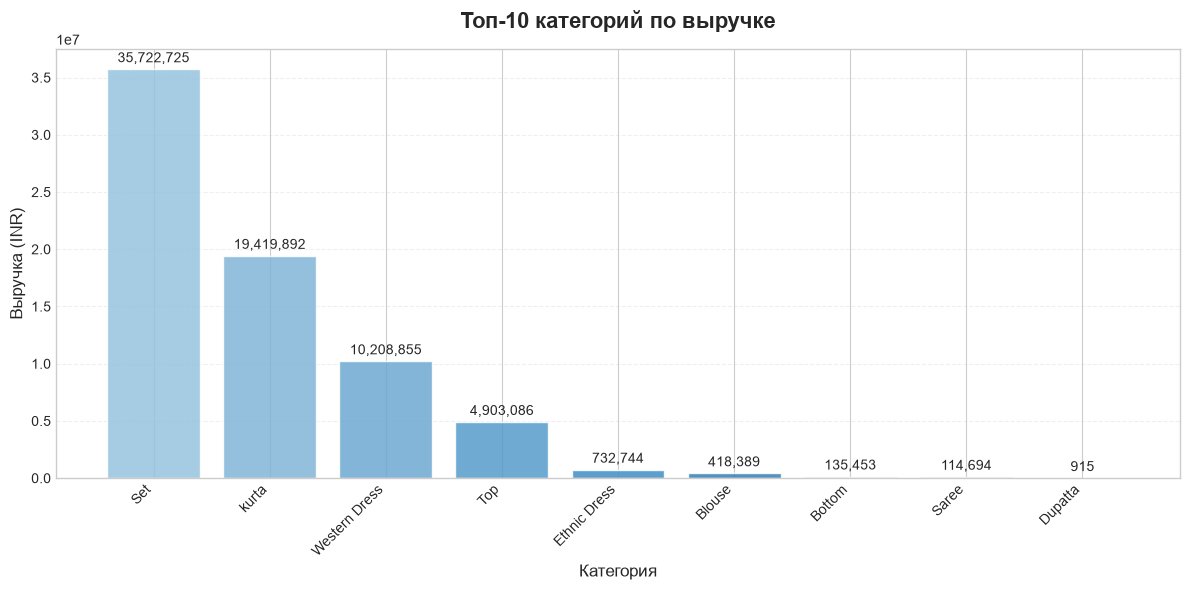

In [51]:
# Для топ-10 категорий по выручке:
# Строю диаграмму, чтобы визуально оценить концентрацию выручки по категориям
# Ожидаю, что топ-3 категории будут давать основную часть выручки

colors_categories = sns.color_palette("Blues_d", n_colors=10)
plot_bar(
    data=top_categories.head(10),
    title='Топ-10 категорий по выручке',
    xlabel='Категория',
    ylabel='Выручка (INR)',
    color=colors_categories,
    value_format='{:,.0f}'
)

## Вывод: концентрация выручки

Из диаграммы выше видно, что топ-3 категории (Set, Kurta, Western Dress) 
дают **91.2% всей выручки**:

| Категория | Выручка (INR) | Доля |
|-----------|---------------|------|
| Set | 35,722,725 | 49.9% |
| Kurta | 19,419,892 | 27.1% |
| Western Dress | 10,208,855 | 14.2% |
| **Итог топ-3** | **65,351,472** | **91.2%** |

### Риски и возможности:
- **Риск:** падение спроса в этих категориях сильно ударит по выручке
- **Возможность:** можно сфокусировать маркетинговые усилия на этих категориях
- **Рекомендация:** диверсифицировать ассортимент, чтобы снизить зависимость от 3 категорий

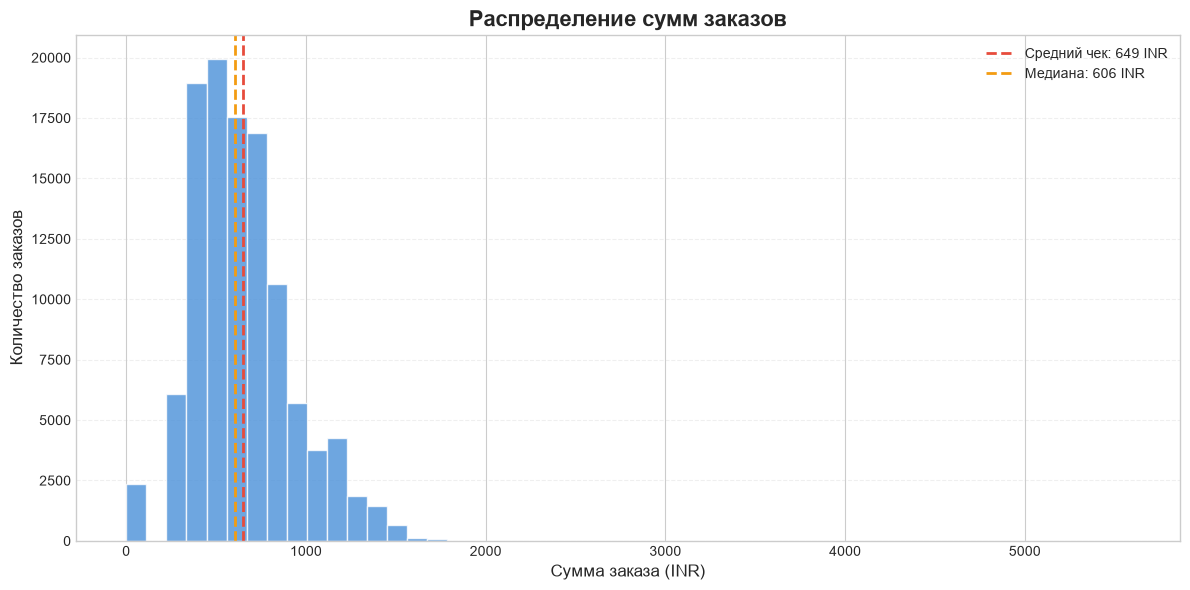

In [26]:
# Строю гистограмму, чтобы понять, как распределены суммы заказов
# Ожидаю, что большинство заказов будут с небольшими суммами, а средний чек будет выше медианы за счёт крупных заказов

plt.figure(figsize=(12, 6))
plt.hist(df_clean['Amount'], bins=50, color=COLORS['blue'], edgecolor='white', alpha=0.8)

plt.axvline(df_clean['Amount'].mean(), color=COLORS['red'], linestyle='--', 
            linewidth=2, label=f'Средний чек: {df_clean["Amount"].mean():.0f} INR')

plt.axvline(df_clean['Amount'].median(), color=COLORS['orange'], linestyle='--', 
            linewidth=2, label=f'Медиана: {df_clean["Amount"].median():.0f} INR')

plt.title('Распределение сумм заказов', fontsize=16, fontweight='bold')
plt.xlabel('Сумма заказа (INR)', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Вывод: распределение сумм заказов

Из гистограммы видно, что:
- **Среднее по позициям:** 649 INR
- **Медиана:** 606 INR
- **AOV (средний чек на заказ):** 695 INR (см. KPI дашборд)

Разница между AOV и средним по позициям (46 INR) объясняется тем, что в заказах с несколькими товарами сумма распределяется между позициями

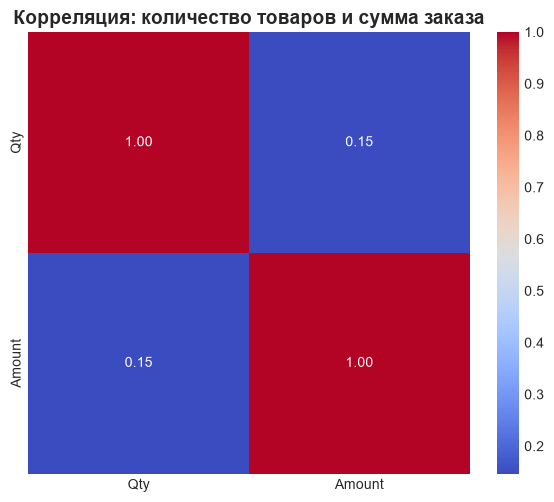

In [52]:
# Корреляция: количество товаров и сумма заказа
# Проверяю, есть ли связь между количеством товаров в заказе и его суммой
# Логично предположить, что чем больше товаров, тем выше сумма

corr_cols = ['Qty', 'Amount']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Корреляция: количество товаров и сумма заказа', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Вывод: корреляция количества товаров и суммы заказа

- **Коэффициент корреляции:** 0.15 (очень слабая связь)
- Можно сделать выод, что **количество товаров в заказе почти не влияет** на его сумму
- Основное влияние на сумму заказа оказывает **цена товара**, а не его количество
- Клиенты чаще покупают **один дорогой товар**, а не несколько дешёвых

### Рекомендация:
Для увеличения среднего чека стоит фокусироваться на дальнейшем продвижении более дорогих товаров и стимулировании покупки нескольких товаров через акции

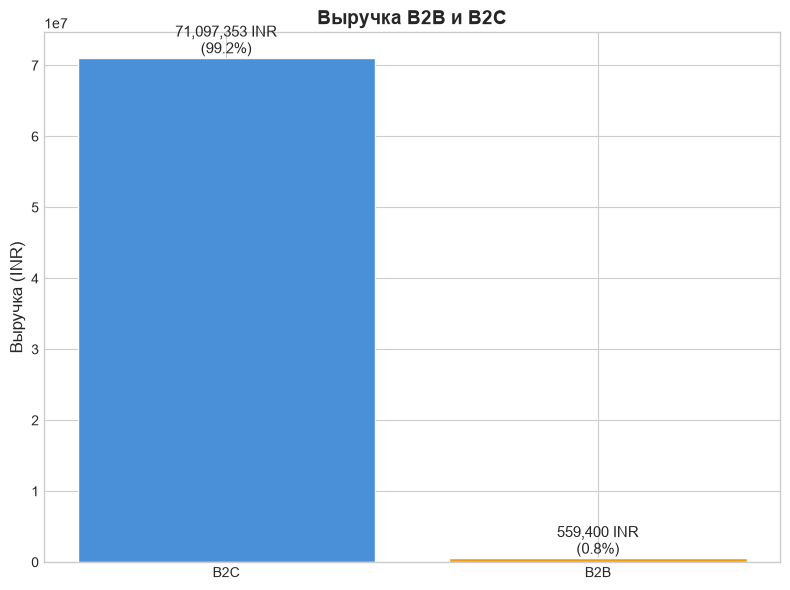

In [53]:
# Доля B2B и B2C заказов:
# Проверяю, какую долю выручки приносит B2B-сегмент. По данным KPI он составляет менее 1%, визуализирую это

labels = ['B2C', 'B2B']
values = [b2c_revenue, b2b_revenue]
percentages = [b2c_revenue/total_revenue*100, b2b_revenue/total_revenue*100]

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=[COLORS['blue'], COLORS['orange']], edgecolor='white', linewidth=1)
plt.title('Выручка B2B и B2C', fontsize=14, fontweight='bold')
plt.ylabel('Выручка (INR)', fontsize=12)

for bar, val, pct in zip(bars, values, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
             f'{val:,.0f} INR\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## Вывод: B2B-сегмент

Из диаграммы видно, что B2B-сегмент составляет **менее 1%** выручки:
- **B2B выручка:** 559,400 INR (0.8%)
- **B2C выручка:** 71,097,353 INR (99.2%)

### Возможные причины:
1. **Неиспользованный канал роста** - нужно исследовать возможности B2B продаж
2. **Ассортимент может не подходить** для корпоративных клиентов
3. **Ценовая политика** не конкурентоспособна для B2B

**Для контекста,** в среднем, по e-commerce B2B-сегмент занимает 5–15% выручки. Наш показатель значительно ниже - это либо неиспользованный канал, либо осознанный выбор бизнес-модели. Нужно провести исследование B2B-рынка и оценить потенциал канала в целом


Количество дней с заказами по месяцам:
 2022-03: 1 дней
 2022-04: 30 дней
 2022-05: 31 дней
 2022-06: 29 дней

Март исключен из графика (всего 1 день)


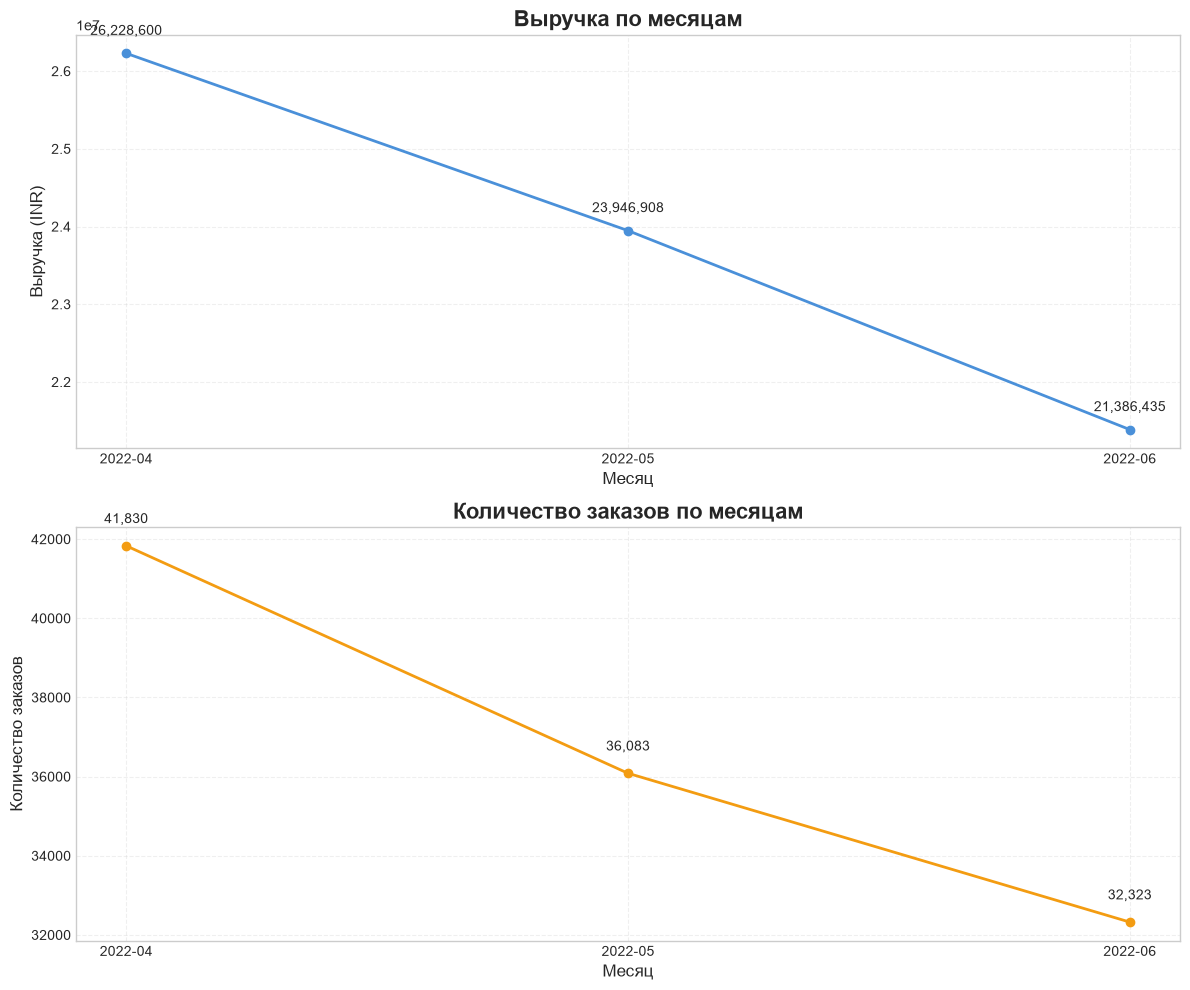

In [54]:
# Динамика по месяцам:
# Добавляю колонку с месяцем для анализа трендов
# Март в данных всего 1 день,поэтому исключаю его из графика

df_clean['Month'] = df_clean['Date'].dt.to_period('M')

monthly_revenue_all = df_clean.groupby('Month')['Amount'].sum()
monthly_orders_all = df_clean.groupby('Month')['Order ID'].count()

# Исключаю март
monthly_revenue = monthly_revenue_all[monthly_revenue_all.index != pd.Period('2022-03', freq='M')]
monthly_orders = monthly_orders_all[monthly_orders_all.index != pd.Period('2022-03', freq='M')]

# Проверяю количество дней в каждом месяце
days_per_month = df_clean.groupby(df_clean['Date'].dt.to_period('M'))['Date'].nunique()
print("\nКоличество дней с заказами по месяцам:")
for month, days in days_per_month.items():
    print(f" {month}: {days} дней")
print("\nМарт исключен из графика (всего 1 день)")

# Визуализация:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Выручка по месяцам
axes[0].plot(monthly_revenue.index.astype(str), monthly_revenue.values, 
             marker='o', linewidth=2, color=COLORS['blue'])
axes[0].set_title('Выручка по месяцам', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Месяц', fontsize=12)
axes[0].set_ylabel('Выручка (INR)', fontsize=12)
axes[0].grid(True, alpha=0.3, linestyle='--')

for i, (month, value) in enumerate(monthly_revenue.items()):
    axes[0].text(i, value + 200000, f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

# Количество заказов по месяцам
axes[1].plot(monthly_orders.index.astype(str), monthly_orders.values, 
             marker='o', linewidth=2, color=COLORS['orange'])
axes[1].set_title('Количество заказов по месяцам', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Месяц', fontsize=12)
axes[1].set_ylabel('Количество заказов', fontsize=12)
axes[1].grid(True, alpha=0.3, linestyle='--')

for i, (month, value) in enumerate(monthly_orders.items()):
    axes[1].text(i, value + 500, f'{value:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Вывод: сезонность

Из графиков видим:

| Месяц | Выручка (INR) | Количество заказов |
|-------|---------------|-------------------|
| Апрель 2022 | ~26,200,000 | ~42,000 |
| Май 2022 | ~24,000,000 | ~36,000 |
| Июнь 2022 | ~21,400,000 | ~32,000 |

- **Пик продаж:** апрель 2022 (26.2 млн INR)
- **Снижение к июню:** ~18% по выручке, ~22% по заказам

### Возможные причины:
- **Сезонность** — весенний всплеск спроса на одежду (апрель)
- **Разовые акции** — возможно, в апреле были запущены какие-либо промо-акции или другие маркетинговые активности

### Рекомендация:
Провести анализ сезонности на данных за полный год, чтобы подтвердить гипотезу о весеннем пике


Выручка по дням недели:
Weekday
Monday       10306831.0
Tuesday      10478329.0
Wednesday    10287678.0
Thursday      9476652.0
Friday        9839561.0
Saturday     10283242.0
Sunday       10984460.0
Name: Amount, dtype: float64

Количество заказов по дням недели:
Weekday
Monday       15869
Tuesday      16139
Wednesday    15924
Thursday     14626
Friday       15125
Saturday     15834
Sunday       16871
Name: Order ID, dtype: int64


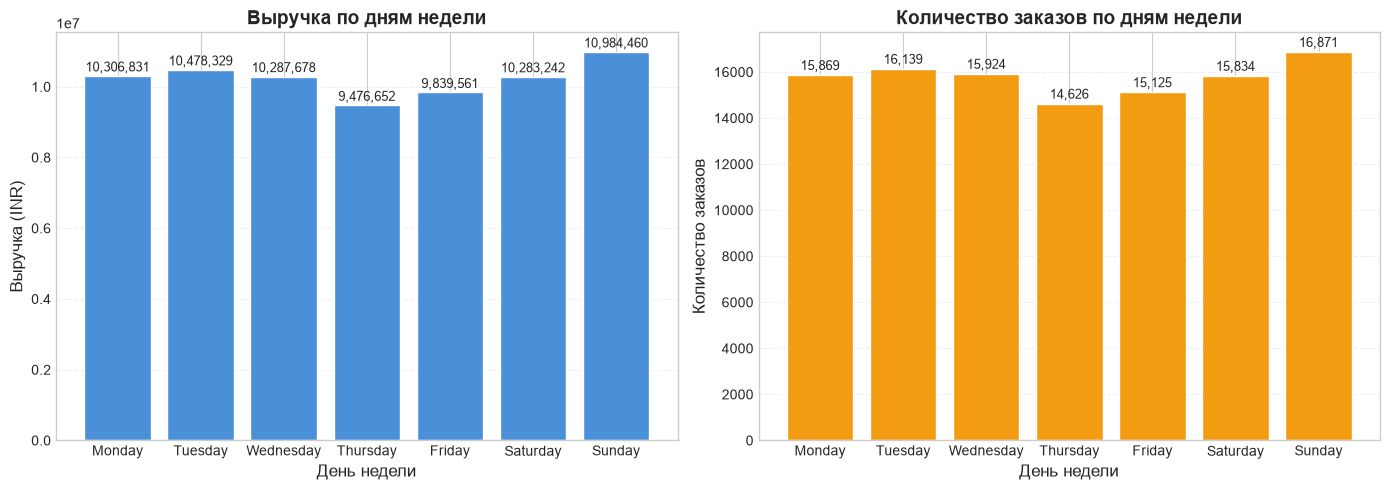

In [55]:
# Анализ выручки по дням недели:
# Добавляю колонку с днём недели, чтобы понять, в какие дни продажи выше чтобы понять как лучше планировать маркетинговые активности и акции

df_clean['Weekday'] = df_clean['Date'].dt.day_name()

# Сортирую дни недели в правильном порядке (понедельник - воскресенье)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_revenue = df_clean.groupby('Weekday')['Amount'].sum().reindex(weekday_order)
weekday_orders = df_clean.groupby('Weekday')['Order ID'].count().reindex(weekday_order)

print("\nВыручка по дням недели:")
print(weekday_revenue)

print("\nКоличество заказов по дням недели:")
print(weekday_orders)

# Визуализация:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Выручка по дням недели
axes[0].bar(weekday_revenue.index, weekday_revenue.values, color=COLORS['blue'], edgecolor='white', linewidth=1)
axes[0].set_title('Выручка по дням недели', fontsize=14, fontweight='bold')
axes[0].set_xlabel('День недели', fontsize=12)
axes[0].set_ylabel('Выручка (INR)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for i, (day, value) in enumerate(weekday_revenue.items()):
    axes[0].text(i, value + 50000, f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

# Количество заказов по дням недели
axes[1].bar(weekday_orders.index, weekday_orders.values, color=COLORS['orange'], edgecolor='white', linewidth=1)
axes[1].set_title('Количество заказов по дням недели', fontsize=14, fontweight='bold')
axes[1].set_xlabel('День недели', fontsize=12)
axes[1].set_ylabel('Количество заказов', fontsize=12)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for i, (day, value) in enumerate(weekday_orders.items()):
    axes[1].text(i, value + 100, f'{value:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Вывод: анализ по дням недели

| День недели | Выручка (INR) | Количество заказов |
|-------------|---------------|-------------------|
| Monday | 10,306,831 | 15,869 |
| Tuesday | 10,478,329 | 16,139 |
| Wednesday | 10,287,678 | 15,924 |
| Thursday | 9,476,652 | 14,626 |
| Friday | 9,839,561 | 15,125 |
| Saturday | 10,283,242 | 15,834 |
| Sunday | 10,984,460 | 16,871 |

### Ключевые выводы:

**Неожиданный инсайт:** пик продаж приходится на **воскресенье** (10.98 млн INR, 16,871 заказов)

**Самый низкий день - четверг** (9.48 млн INR, 14,626 заказов), что на **13.7% ниже** воскресного пика

**AOV по дням недели стабилен** — выручка и количество заказов движутся синхронно:

| День недели | AOV (INR) |
|-------------|-----------|
| Monday | 649.4 |
| Tuesday | 649.3 |
| Wednesday | 646.0 |
| Thursday | 647.9 |
| Friday | 650.5 |
| Saturday | 649.4 |
| Sunday | 651.1 |

**Разница AOV между максимумом и минимумом - всего 5 INR** (0.8%). Можно сделать вывод о **стабильности в поведении покупателей** независимо от дней недели

### Возможные причины воскресного пика:
1. **Люди делают покупки в выходные** из-за больше свободного времени для шопинга
2. **Воскресные акции** — возможно, магазин запускает скидки в выходные
3. **Аудитория** — работающие люди, которые покупают в выходной

### Рекомендации:
1. **Запускать основные акции и рассылки в воскресенье** — в этот день аудитория наиболее активна
2. **В четверг предлагать специальные скидки** — чтобы стимулировать спрос в "плохой" день
3. **Протестировать push-уведомления в пятницу вечером** — чтобы разогреть аудиторию для покупок перед воскресным пиком

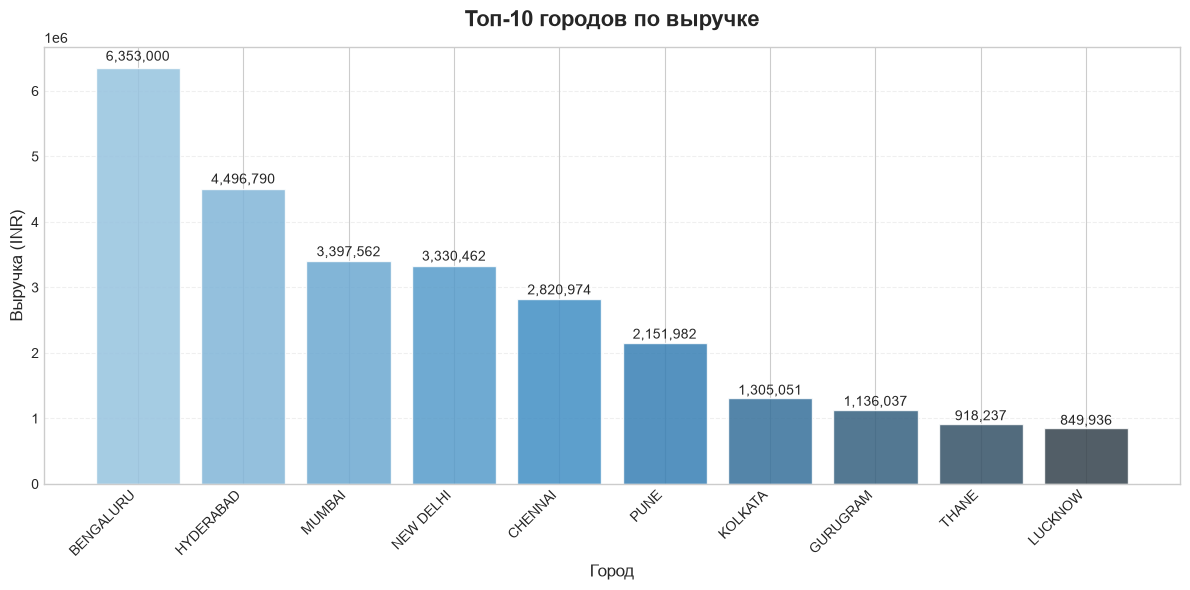

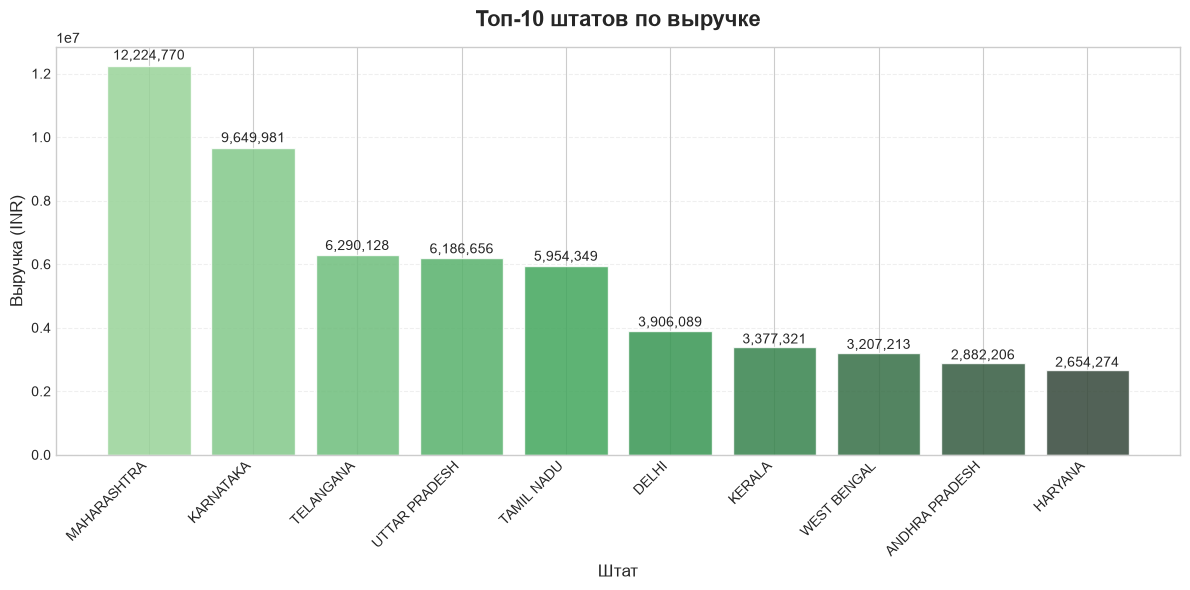

In [11]:
# Топ-10 городов по выручке:
# Строю диаграмму, чтобы понять географическую концентрацию продаж

colors_cities = sns.color_palette("Blues_d", n_colors=10)
plot_bar(
    data=top_cities.head(10),
    title='Топ-10 городов по выручке',
    xlabel='Город',
    ylabel='Выручка (INR)',
    color=colors_cities,
    value_format='{:,.0f}'
)

# Топ-10 штатов по выручке:
colors_states = sns.color_palette("Greens_d", n_colors=10)
plot_bar(
    data=top_states.head(10),
    title='Топ-10 штатов по выручке',
    xlabel='Штат',
    ylabel='Выручка (INR)',
    color=colors_states,
    value_format='{:,.0f}'
)

## Вывод: география продаж

Из диаграмм выше видно:

**Топ-5 городов по выручке:**

| Город | Выручка (INR) |
|-------|---------------|
| BENGALURU | 6,350,000 |
| HYDERABAD | 4,500,000 |
| MUMBAI | 3,400,000 |
| New Delhi | 3,300,000 |
| Chennai | 2,800,000 |

**Топ-7 штатов по выручке:**

| Штат | Выручка (INR) |
|------|---------------|
| MAHARASHTRA | 12,200,000 |
| KARNATAKA | 9,600,000 |
| TELANGANA | 6,300,000 |
| UTTAR PRADESH | 6,200,000 |
| TAMIL NADU | 6,000,000 |
| DELHI | 3,900,000 |

### Ключевые выводы:
- **Бенгалуру** - город-лидер (6.35M INR), но **Махараштра** штат-лидер (12.2M INR) за счёт Мумбаи и других городов
- **Концентрация в южной Индии** — Karnataka, Telangana, Tamil Nadu дают ~22M INR (30% выручки)
- **Разрыв между штатами** — Maharashtra (12.2M) v.s Delhi (3.9M) — в 3 раза

### Рекомендации:
1. **Усилить маркетинг в Maharashtra** , тк там уже есть база (Мумбаи), и можно масштабировать
2. **Проанализировать низкую выручку в Delhi** — при населении 30M+ выручка всего 3.9M
3. **Рассмотреть логистику в южной Индии** по Karnataka, Tamil Nadu, Telangana

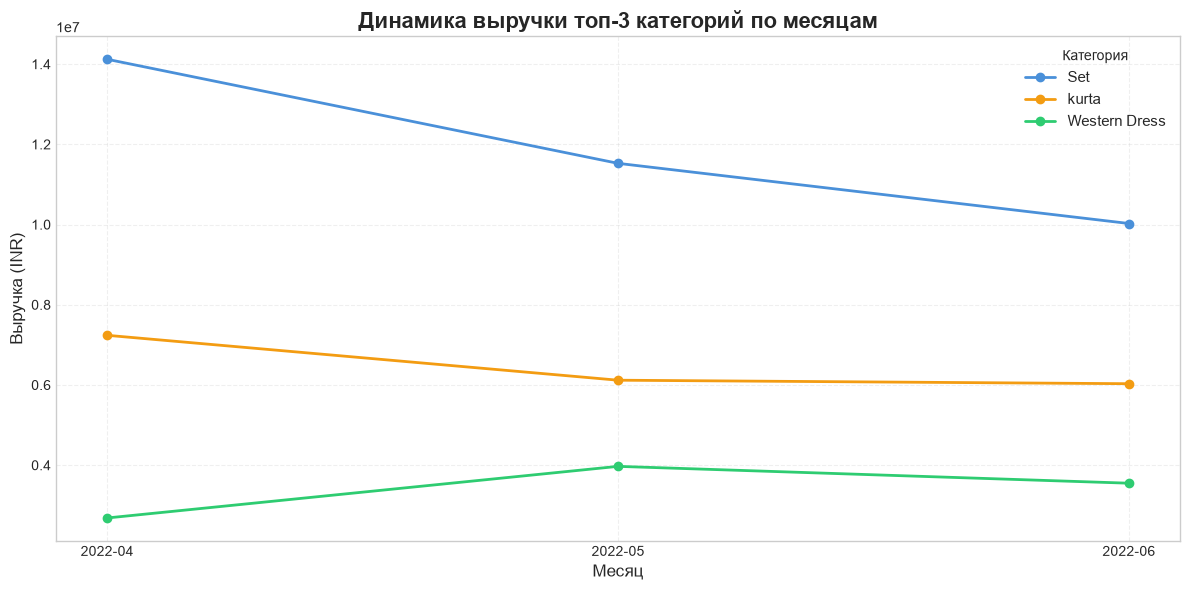

In [56]:
# Динамика выручки топ-3 категорий по месяцам:
# Смотрю, как меняется выручка по категориям в динамике, это помогает понять, какие категории растут, а какие падают

category_monthly = df_clean.pivot_table(
    index='Month', 
    columns='Category', 
    values='Amount', 
    aggfunc='sum'
)

top3 = top_categories.head(3).index.tolist()
colors_top3 = [COLORS['blue'], COLORS['orange'], COLORS['green']]

plt.figure(figsize=(12, 6))
for cat, color in zip(top3, colors_top3):
    data = category_monthly[cat]
    data = data[data.index != pd.Period('2022-03', freq='M')]
    plt.plot(data.index.astype(str), data.values, 
             marker='o', linewidth=2, color=color, label=cat)

plt.title('Динамика выручки топ-3 категорий по месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Выручка (INR)', fontsize=12)
plt.legend(title='Категория', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Вывод: динамика топ-категорий

Из графика выше видно, что категории показывают довольно **разную динамику**:

| Категория | Апрель | Май | Июнь | Тренд |
|-----------|--------|-----|------|-------|
| Set | **Пик** | Падение | Падение | Резкий взлёт в апреле, затем линейное снижение |
| Kurta | Пик | Падение | **Прямая** | Пик в апреле, падение в мае, стагнация в июне |
| Western Dress | **Нижняя точка** | **Пик** | Падение | Рост к маю, затем падение |

### Ключевые выводы:

1. **Set** — резкий пик в апреле, затем линейное снижение. Возможно, апрельские акции были сфокусированы на этой категории

2. **Kurta** — пик в апреле, падение в мае, затем стагнация. В июне продажи стабилизировались

3. **Western Dress** — минимальные продажи в апреле, пик в мае, затем падение. Возможно, другая аудитория или отложенный спрос

### Возможные причины:
- **Апрельские акции** были сфокусированы на Set и Kurta
- **Western Dress** — другая аудитория (покупает позже)
- **Общий спад к июню** — сезонность

### Рекомендации:
1. **Проверить маркетинговые активности в апреле и мае** — возможно, акции были разными для разных категорий
2. **Проанализировать аудиторию Western Dress** — возможно, это другая целевая группа
3. **Провести анализ сезонности на данных за полный год**


Распределение статусов заказов:
Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

Всего заказов: 128,975
Успешно доставлено: 106,573 (82.6%)
Отменено: 18,332 (14.2%)


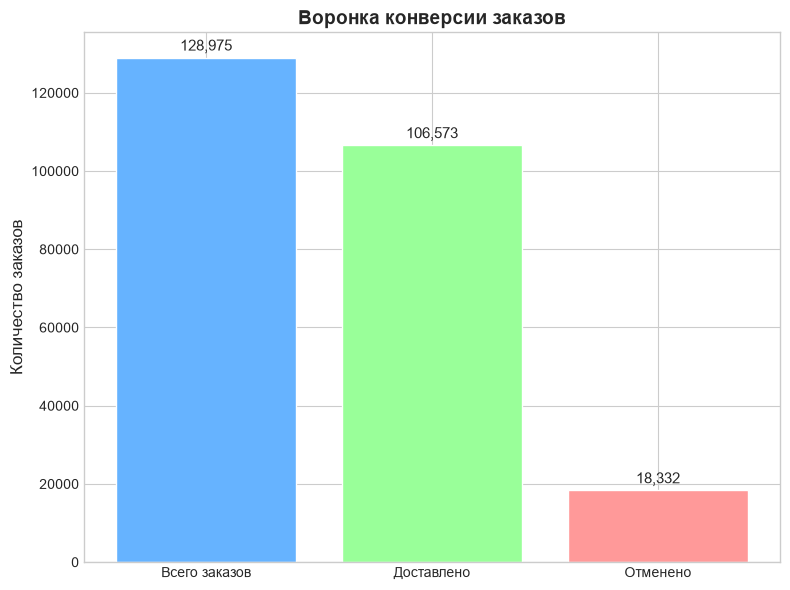

In [37]:
# Воронка конверсии заказов
# Анализирую, сколько заказов было успешно доставлено, а сколько отменено

status_counts = df['Status'].value_counts()
print("\nРаспределение статусов заказов:")
print(status_counts)

success_statuses = ['Shipped - Delivered to Buyer', 'Shipped']
total_orders_raw = len(df)
success_orders = df[df['Status'].isin(success_statuses)].shape[0]
cancelled_orders = df[df['Status'] == 'Cancelled'].shape[0]

print(f"\nВсего заказов: {total_orders_raw:,}")
print(f"Успешно доставлено: {success_orders:,} ({success_orders/total_orders_raw*100:.1f}%)")
print(f"Отменено: {cancelled_orders:,} ({cancelled_orders/total_orders_raw*100:.1f}%)")

# Визуализация
stages = ['Всего заказов', 'Доставлено', 'Отменено']
values = [total_orders_raw, success_orders, cancelled_orders]
colors_funnel = ['#66b3ff', '#99ff99', '#ff9999']

plt.figure(figsize=(8, 6))
bars = plt.bar(stages, values, color=colors_funnel, edgecolor='white', linewidth=1)
plt.title('Воронка конверсии заказов', fontsize=14, fontweight='bold')
plt.ylabel('Количество заказов', fontsize=12)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
             f'{val:,}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## Вывод: воронка конверсии и статусы

| Этап | Количество | Доля |
|------|------------|------|
| Всего заказов | 128,975 | 100% |
| В пути (Shipped) | 77,804 | 60.3% |
| Успешно доставлено | 28,769 | 22.3% |
| Отменено | 18,332 | 14.2% |
| Возвращено | 2,098 | 1.6% |
| Остальные статусы | 1,972 | 1.5% |

### Ключевые выводы:

1. **60.3% заказов в пути** — это очень много, данные за март-июнь, возможно, часть заказов ещё не доставлена, либо у магазина **долгая логистика**, что может являться проблемой

2. **22.3% успешно доставлены** — не плохой показатель, но могло быть и больше

3. **14.2% отмен** — значительная потеря. Возможные причины: отсутствие товара, проблемы с оплатой, клиенты передумали

4. **1.6% возвратов** — низкий показатель

5. **Остальные статусы** — менее 2%. Это заказы в статусе процесса (Picked Up, Out for Delivery, Pending)

### Рекомендации:
1. **Оптимизировать логистику** — сократить время доставки, чтобы заказы не висели в статусе "Shipped"
2. **Проанализировать причины отмен** — добавить поле "причина отмены"
3. **Улучшить отслеживание заказов** — чтобы клиенты видели статус
4. **Сократить время доставки** — особенно в городах с высоким уровнем отмен


Статистика по возвратам:
----------------------------------------
Всего заказов: 128,975
Возвратов: 2,098 (1.63%)

Доля возвратов по категориям:
Category
Western Dress    2.206452
Set              1.668523
kurta            1.503699
Ethnic Dress     1.380500
Bottom           1.363636
Blouse           1.295896
Top              1.242704
Saree            0.609756
Dupatta               NaN
Name: count, dtype: float64


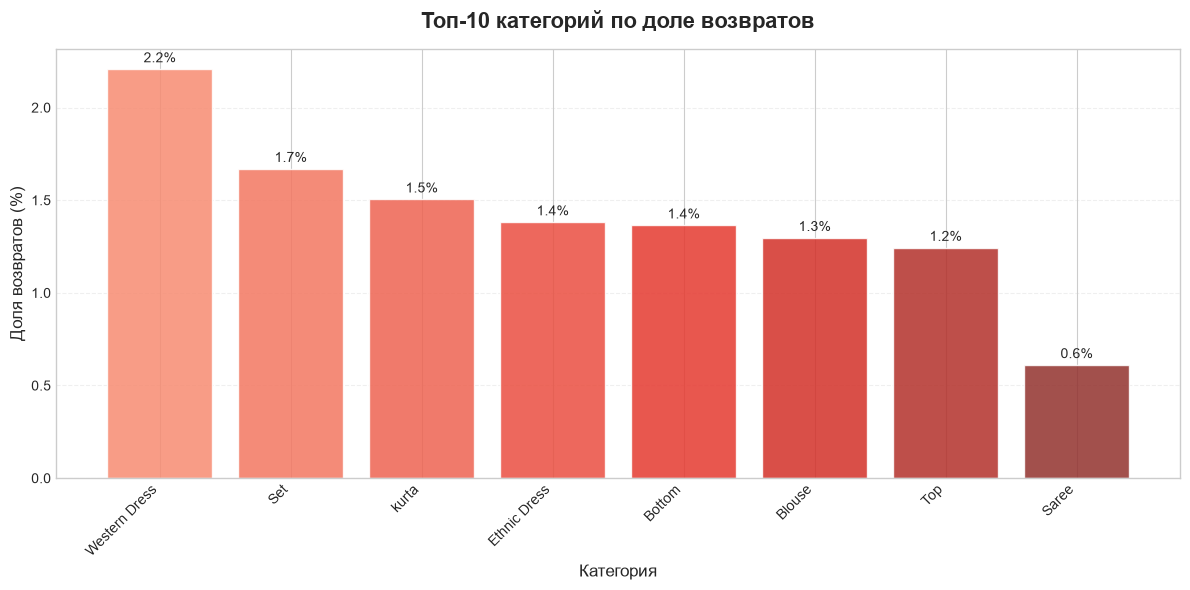


Топ-5 городов по доле возвратов:
ship-city
COOCH BEHAR             100.0
MANGALBARI              100.0
MURTAJAPUR              100.0
Madanapalli Chittoor    100.0
Belgharia Nimta         100.0
Name: count, dtype: float64

Статусы возвратов:
Status
Shipped - Returned to Seller     1953
Shipped - Returning to Seller     145
Name: count, dtype: int64


In [57]:
# Анализирую, какие категории и города чаще всего возвращают товары, чтобы понять где есть проблемы с качеством или ожиданиями клиентов

returned_orders = df[df['Status'].str.contains('Return', case=False, na=False)]
returned_count = len(returned_orders)
total_orders_raw = len(df)

print("\nСтатистика по возвратам:")
print("-" * 40)
print(f"Всего заказов: {total_orders_raw:,}")
print(f"Возвратов: {returned_count:,} ({returned_count/total_orders_raw*100:.2f}%)")

# Возвраты по категориям:
returned_by_category = returned_orders['Category'].value_counts()
total_by_category = df['Category'].value_counts()
return_rate_by_category = (returned_by_category / total_by_category * 100).sort_values(ascending=False)

print("\nДоля возвратов по категориям:")
print(return_rate_by_category)

# Топ-категории по доле возвратов
colors_return = sns.color_palette("Reds_d", n_colors=10)
plot_bar(
    data=return_rate_by_category.head(10),
    title='Топ-10 категорий по доле возвратов',
    xlabel='Категория',
    ylabel='Доля возвратов (%)',
    color=colors_return,
    value_format='{:.1f}%'
)

# Возвраты по городам 
returned_by_city = returned_orders['ship-city'].value_counts()
total_by_city = df['ship-city'].value_counts()
return_rate_by_city = (returned_by_city / total_by_city * 100).sort_values(ascending=False)

print("\nТоп-5 городов по доле возвратов:")
print(return_rate_by_city.head(5))

# Возвраты по статусам 
return_statuses = returned_orders['Status'].value_counts()
print("\nСтатусы возвратов:")
print(return_statuses)

## Вывод: анализ возвратов

### Общая статистика
- **Всего заказов:** 128,975
- **Возвратов:** 2,098 (1.63%)
- Уровень возвратов **низкий** (менее 2%) - это очень хороший показатель


### Доля возвратов по категориям

| Категория | Доля возвратов | Комментарий |
|-----------|----------------|-------------|
| Western Dress | 2.21% | Самый высокий показатель |
| Set | 1.67% | Низкий для самой популярной категории |
| kurta | 1.50% | Средний |
| Ethnic Dress | 1.38% | Средний |
| Bottom | 1.36% | Средний |
| Blouse | 1.30% | Средний |
| Top | 1.24% | Средний |
| Saree | 0.61% | Очень низкий |
| Dupatta | 0.00% | Ни одного возврата |

### Ключевые выводы по категориям:

1. **Western Dress — лидер по возвратам (2.21%)**
   - Возможные причины: неправильная сетка размера, качество ткани, несоответствие ожиданиям
   - **Рекомендация:** проработать более явные таблицы размеров, добавить видео-обзоры, предлагать отзывы с фото


2. **Set — низкий уровень возвратов (1.67%)**
   - Несмотря на то, что Set даёт 49.9% выручки, возвратов немного
   - Это говорит о **высоком качестве товара** и **соответствии ожиданиям** клиентов

3. **Dupatta — 0% возвратов**
   - Самый безопасный товар - низкая цена, не нужна примерка


### Критический инсайт: города с 100% возвратов

| Город | Доля возвратов |
|-------|----------------|
| COOCH BEHAR | 100% |
| MANGALBARI | 100% |
| MURTAJAPUR | 100% |
| Madanapalli Chittoor | 100% |
| Belgharia Nimta | 100% |

**Это не может быть случайностью,** в этих городах **каждый заказ возвращён**.

#### Возможные причины:
1. **Проблемы с логистикой** — заказы просто не доходят до клиентов
2. **Системная ошибка** — неправильно проставлен статус "Returned"
3. **Мошенничество** — заказы оформляются на подставные адреса
4. **Проблемы с доставкой в регионе** — курьерская служба не справляется или путает товары

#### Рекомендации:
1. **Связаться с логистической службой** по этим городам
2. **Проверить каждый заказ вручную** — подтвердить, что это действительно возвраты
3. **Временно приостановить приём заказов** в этих городах до устранения ошибок/выяснения причин


### Статусы возвратов

| Статус | Количество |
|--------|------------|
| Shipped - Returned to Seller | 1,953 (93.1%) |
| Shipped - Returning to Seller | 145 (6.9%) |

**Вывод:** большинство возвратов (93.1%) уже дошли до продавца, значит процесс возврата работает актуально


### Итоговые рекомендации

1. **Проверить города с 100% возвратов** — главная проблема
2. **Улучшить товар Western Dress** — проработать причины отказов
3. **Собирать причины возвратов** — добавить поле "причина возврата"
4. **Проанализировать логистику** — возможно, проблемой является в конкретный перевозчик


Детальное распределение статусов заказов:
--------------------------------------------------
Доставлено: 28,769 (22.3%)
В пути: 78,812 (61.1%)
Возвращено: 2,098 (1.6%)
Отменено: 18,332 (14.2%)
Проблемы: 17 (0.0%)
Ожидание: 947 (0.7%)


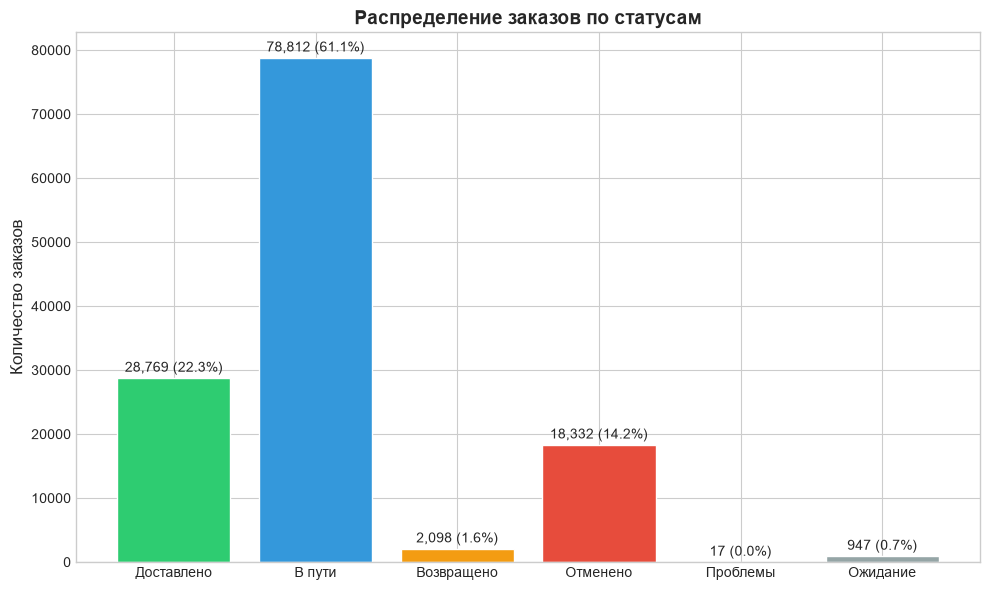

In [58]:
# Проведу детальный анализ статусов заказов
# Разбиваю все статусы на группы, чтобы понять полную картину.

status_counts = df['Status'].value_counts()

print("\nДетальное распределение статусов заказов:")
print("-" * 50)

# Группирую статусы
status_groups = {
    'Доставлено': ['Shipped - Delivered to Buyer'],
    'В пути': ['Shipped', 'Shipped - Picked Up', 'Shipped - Out for Delivery'],
    'Возвращено': ['Shipped - Returned to Seller', 'Shipped - Returning to Seller'],
    'Отменено': ['Cancelled'],
    'Проблемы': ['Shipped - Lost in Transit', 'Shipped - Damaged', 'Shipped - Rejected by Buyer'],
    'Ожидание': ['Pending', 'Pending - Waiting for Pick Up', 'Shipping']
}

group_counts = {}
for group, statuses in status_groups.items():
    count = df[df['Status'].isin(statuses)].shape[0]
    group_counts[group] = count
    print(f"{group}: {count:,} ({count/len(df)*100:.1f}%)")

# Визуализация
plt.figure(figsize=(10, 6))
colors_status = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C', '#E67E22', '#95A5A6']
bars = plt.bar(group_counts.keys(), group_counts.values(), color=colors_status, edgecolor='white', linewidth=1)

plt.title('Распределение заказов по статусам', fontsize=14, fontweight='bold')
plt.ylabel('Количество заказов', fontsize=12)
plt.xticks(rotation=0)

for bar, (group, count) in zip(bars, group_counts.items()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{count:,} ({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Вывод: детальный анализ статусов

| Статус | Количество | Доля |
|--------|------------|------|
| В пути | 78,812 | 61.1% |
| Доставлено | 28,769 | 22.3% |
| Отменено | 18,332 | 14.2% |
| Возвращено | 2,098 | 1.6% |
| Ожидание | 947 | 0.7% |
| Проблемы | 17 | 0.01% |

### Ключевые выводы:

**1. 61.1% заказов в пути — самый большой сегмент**
- Данные за март-июнь, часть заказов из марта-апреля уже должны были быть доставлены
- Возможно, у магазина долгая логистика 
- **Рекомендация:** проверить среднее время доставки

**2. 22.3% успешно доставлены** — нормальный показатель, но могло быть и больше

**3. 14.2% отмен — значительный показатель**
- Возможные причины: отсутствие товара, проблемы с оплатой
- **Рекомендация:** проанализировать причины отмен

**4. 1.6% возвратов — низкий показатель**
- Говорит о хорошем качестве товаров и сервиса

**5. 0.7% в ожидании** — заказы, которые ещё не начали обрабатывать
- **Рекомендация:** проверить, почему заказы зависают в статусе "Pending"

### Общие рекомендации:
1. Оптимизировать логистику — сократить время доставки
2. Проанализировать причины отмен — добавить поле "причина отмены"
3. Улучшить отслеживание заказов — чтобы клиенты видели актуальный статус и обновления по нему
4. Проверить 17 проблемных заказов — возможно, системная ошибка

In [59]:
# Сравнение среднего чека: топ-3 категории / все остальные:
# По графикам видно, что Set, kurta и Western Dress сильно выделяются
# Проверяю, действительно ли у них выше средний чек, или это случайность

from scipy import stats
import numpy as np

top3_categories = ['Set', 'kurta', 'Western Dress']

df_top3 = df_clean[df_clean['Category'].isin(top3_categories)]
df_other = df_clean[~df_clean['Category'].isin(top3_categories)]

mean_top3 = df_top3['Amount'].mean()
mean_other = df_other['Amount'].mean()
print(f"\nСредний чек топ-3: {mean_top3:.2f} INR")
print(f"Средний чек остальных: {mean_other:.2f} INR")
print(f"Разница: {mean_top3 - mean_other:.2f} INR ({((mean_top3/mean_other - 1)*100):.1f}%)")

# T-test для независимых выборок
# Проверяю гипотезу: у топ-3 категорий средний чек выше, чем у остальных
# Это важно для понимания, стоит ли фокусироваться на этих категориях с точки зрения маржинальности и маркетинга

t_stat, p_value = stats.ttest_ind(df_top3['Amount'], df_other['Amount'], equal_var=False)
print(f"t-test: t={t_stat:.4f}, p-value={p_value:.4f}")

# При таком объёме данных (n > 100k) p-value почти всегда будет < 0.05
# Поэтому добавляю cohen's d - он показывает, насколько разница важна на практике

n1, n2 = len(df_top3), len(df_other)
s1, s2 = df_top3['Amount'].std(), df_other['Amount'].std()
pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = (mean_top3 - mean_other) / pooled_std
print(f"Cohen's d: {cohens_d:.3f}")

# При большом объеме данных (n > 100k) p-value почти всегда < 0.05, поэтому основной вывод - по размеру эффекта

if cohens_d >= 0.5:
    print("Вывод: разница средних умеренная (d >= 0.5)")
else:
    print("Вывод: разница средних небольшая (d < 0.5)")

# Итоговый вывод - чтобы было понятно, что результат значит
if p_value < 0.05 and cohens_d >= 0.2:
    print("Вывод: разница статистически значима и практически заметна")
else:
    print("Вывод: разница статистически значима, но эффект очень маленький")


Средний чек топ-3: 662.06 INR
Средний чек остальных: 539.93 INR
Разница: 122.13 INR (22.6%)
t-test: t=64.2067, p-value=0.0000
Cohen's d: 0.435
Вывод: разница средних небольшая (d < 0.5)
Вывод: разница статистически значима и практически заметна


### Интерпретация:

- Разница **статистически значима** (p-value < 0.001) — это не случайность
- Эффект **небольшой** (Cohen's d = 0.435, близко к пограничному значению 0.5)
- Разница в 22.6% **реальна**, но её **практическая значимость ограничена**

### Что это значит для бизнеса:

| Аспект | Вывод |
|--------|-------|
| **Стоит ли фокусироваться на топ-категориях** | Да, т.к. они дают 91% выручки |
| **Поможет ли это сильно поднять AOV** | Нет, т.к эффект небольшой |
| **Что выступает как основной драйвер роста** | **Объём продаж**, а не в высоком чеке |

### Рекомендация:

Фокусироваться на топ-категориях **имеет смысл**, но это не изменит кардинально средний чек. Основной драйвер выручки это **объём продаж**, а не высокий чек

Для роста AOV может быть более эффективно:
1. **Кросс-продажи** — предлагать сопутствующие товары
2. **Акции "купи 2, получи скидку"** — стимулировать покупку нескольких товаров
3. **Продвижение более дорогих товаров** — в тех же категориях


Статистика по сегментам заказов:
             count      mean  min  max
segment                               
1 товар      97174  1.000000    1    1
2-3 товара    5598  2.130940    2    3
4-5 товаров    240  4.233333    4    5
6+ товаров      36  7.472222    6   12


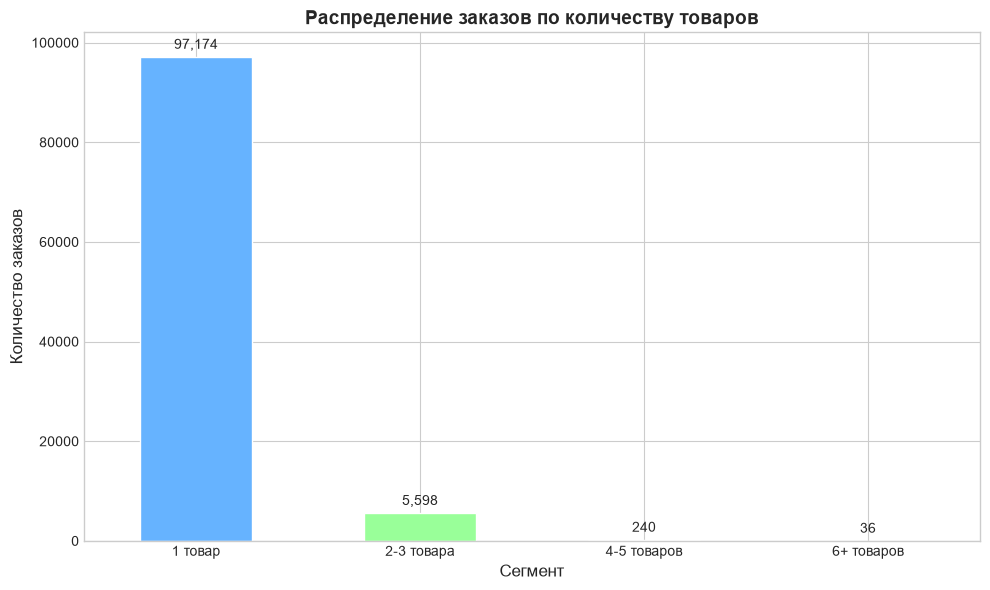

In [60]:
# Сегментация заказов по количеству товаров:
# Проверяю, сколько товаров в среднем в одном заказе.

order_items = df_clean.groupby('Order ID').size().reset_index(name='items_count')

def segment_order_size(count):
    if count == 1:
        return '1 товар'
    elif count <= 3:
        return '2-3 товара'
    elif count <= 5:
        return '4-5 товаров'
    else:
        return '6+ товаров'

order_items['segment'] = order_items['items_count'].apply(segment_order_size)

segment_stats = order_items.groupby('segment')['items_count'].agg(['count', 'mean', 'min', 'max'])
print("\nСтатистика по сегментам заказов:")
print(segment_stats)

# Визуализация
plt.figure(figsize=(10, 6))
colors_seg = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']
order_items['segment'].value_counts().plot(kind='bar', color=colors_seg, edgecolor='white', linewidth=1)
plt.title('Распределение заказов по количеству товаров', fontsize=14, fontweight='bold')
plt.xlabel('Сегмент', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.xticks(rotation=0)

for i, val in enumerate(order_items['segment'].value_counts().values):
    plt.text(i, val + 1000, f'{val:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Вывод: сегментация по количеству товаров

| Сегмент | Количество заказов | Доля |
|---------|-------------------|------|
| 1 товар | 97,174 | 94.2% |
| 2-3 товара | 5,598 | 5.4% |
| 4-5 товаров | 240 | 0.2% |
| 6+ товаров | 36 | 0.03% |

### Ключевые выводы:
- **97% заказов содержат 1 товар** — можем сделать вывод о преимущественно одиночных покупках
- Это важный инсайт для команды маркетинга

### Что это значит:
- **Основной формат покупки** — один товар за раз
- **Потенциал для роста AOV** — через стимулирование покупки нескольких товаров
- **Корреляция Qty / Amount = 0.15** объясняется именно этим, тк вариативности почти нет

### Рекомендация:
Протестировать акции "купи 2, получи скидку" для стимулирования покупки нескольких товаров


Система алертов (скользящее среднее + 3σ)
--------------------------------------------------
Период: 2022-03-31 00:00:00 — 2022-06-29 00:00:00
Дней: 91
Средняя дневная выручка: 787,437 INR
Найдено аномалий: 0
Аномалий не обнаружено — выручка стабильна в наблюдаемый период


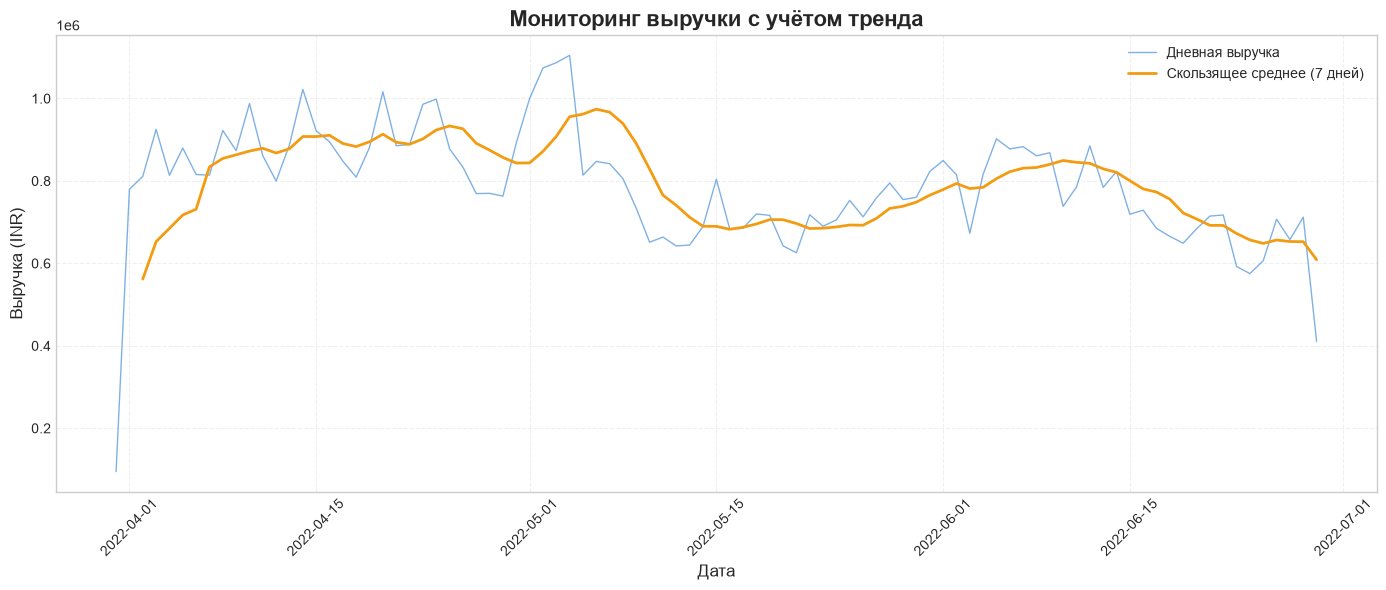

In [61]:
# Система алертов: скользящее среднее + 3 сигмы:
# Сначала пробовала обычное 3 сигмы от глобального среднего, но из-за тренда оно находило аномалии в начале и конце периода
# Скользящее среднее лучше адаптируется к локальным изменениям

daily_revenue = df_clean.groupby('Date')['Amount'].sum().sort_index()

# Окно 7 дней - условная "неделя", чтобы сгладить ежедневные колебания
# min_periods=3 - чтобы не вылетало на первых днях с малым числом наблюдений

rolling_mean = daily_revenue.rolling(window=7, min_periods=3).mean()
rolling_std = daily_revenue.rolling(window=7, min_periods=3).std()

# 3 сигмы - классический порог,который отсекает ~0.3% точек
threshold = 3 * rolling_std
anomalies = daily_revenue[abs(daily_revenue - rolling_mean) > threshold]

print("\nСистема алертов (скользящее среднее + 3σ)")
print("-" * 50)
print(f"Период: {daily_revenue.index.min()} — {daily_revenue.index.max()}")
print(f"Дней: {len(daily_revenue)}")
print(f"Средняя дневная выручка: {daily_revenue.mean():,.0f} INR")
print(f"Найдено аномалий: {len(anomalies)}")

if len(anomalies) > 0:
    print("\nАномальные дни:")
    for date, amount in anomalies.items():
        dev = amount - rolling_mean[date]
        print(f"  {date.strftime('%Y-%m-%d')}: {amount:,.0f} INR "
              f"(отклонение от тренда: {dev:+,.0f} INR)")
else:
    print("Аномалий не обнаружено — выручка стабильна в наблюдаемый период")

# Визуализация - точки на графике сразу покажут, где выбросы
plt.figure(figsize=(14, 6))
plt.plot(daily_revenue.index, daily_revenue.values,
         label='Дневная выручка', alpha=0.7, linewidth=1, color=COLORS['blue'])
plt.plot(rolling_mean.index, rolling_mean.values,
         label='Скользящее среднее (7 дней)', color=COLORS['orange'], linewidth=2)

for date in anomalies.index:
    plt.scatter(date, anomalies[date], color=COLORS['red'], s=150, zorder=5,
                edgecolor='white', linewidth=1)

plt.title('Мониторинг выручки с учётом тренда', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Выручка (INR)', fontsize=12)
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Вывод: система алертов

- **Период анализа:** 31 марта – 29 июня 2022
- **Количество дней:** 91
- **Средняя дневная выручка:** 787,437 INR
- **Найдено аномалий:** 0

### Интерпретация:

Отсутствие аномалий говорит о том, что выручка была **стабильной** в наблюдаемый период

**Однако,** при 3σ мы ожидаем ~0.3% точек за пределами порога (примерно 1 день из 300). То, что мы не нашли ни одной аномалии за 91 день, может означать что

1. **Данные действительно стабильны** — значит, бизнес предсказуем
2. **Порог 3σ слишком широкий** — для этого бизнеса стоит использовать 2.5σ или индивидуальные пороги по дням недели

### Рекомендация:

Метод скользящего среднего + 3σ **работает** но для повышения чувствительности, можно:

1. Настроить пороги **индивидуально для каждого дня недели**
2. Использовать **2.5σ** для более раннего обнаружения отклонений
3. Добавить **STL-декомпозицию** для учёта сезонности

# Итоги

## Ключевые инсайты

### 1. Концентрация выручки
Топ-3 категории (Set, Kurta, Western Dress) дают **91% всей выручки**

### 2. Структура заказов
- **97% заказов содержат 1 товар** — пользователи предпочитают формат одиночных покупок
- **Средний чек:** 695 INR
- Есть потенциал роста AOV через кросс-продажи

### 3. Сезонность
- Пик продаж — апрель 2022 (26.2 млн INR)
- К июню заметно снижение на ~21%

### 4. B2B-сегмент
- Менее **1% выручки** (559,400 INR из 71.6M INR) — бизнес практически полностью B2C

### 5. География
- **Бенгалуру** — город-лидер (6.35M INR)
- **Махараштра** — штат-лидер (12.2M INR)
- Бизнес сконцентрирован в Южной Индии

### 6. Отмены заказов
- **14.2%** заказов отменены — значительный показатель

### 7. Возвраты
- **1.6%** возвратов — низкий показатель, что хорошо
- **Western Dress** — лидер по возвратам (2.21%)
- **5 городов с 100% возвратов** — критическая проблема

### 8. Дни недели
- **Воскресенье** — пик продаж (10.98M INR)
- **Четверг** — самый низкий по активности день (9.48M INR)
- AOV стабилен по дням недели (разница 5 INR)

### 9. Статистика
- Средний чек в топ-категориях выше на 22.6%
- Эффект небольшой (Cohen's d = 0.435)

### 10. Аномалии
- За период не выявлено аномальных дней


## Рекомендации

1. **Сфокусировать маркетинг на топ-категориях** — они дают 91% выручки
2. **Протестировать акции "купи 2, получи скидку"** — 97% заказов с 1 товаром
3. **Исследовать B2B-сегмент** — потенциально неиспользованный канал
4. **Проанализировать причины отмен заказов** — 14.2% — это достаточно много
5. **Собирать Customer ID** — для анализа удержания и LTV
6. **Использовать систему алертов для мониторинга** — метод работает
7. **Проверить города с 100% возвратов** — COOCH BEHAR, MANGALBARI и тд.
8. **Запускать акции в воскресенье** — пиковый день продаж
9. **Улучшить качество Western Dress** — детальные таблицы размеров, отзывы


## Ограничения

- Данные охватывают только 3 полных месяца
- Нет Customer ID — сегментация только по заказам


## Next Steps

- Добавить данные за полный год для анализа сезонности
- Внедрить STL-декомпозицию для учёта сезонности
- Провести A/B-тест для проверки гипотез о среднем чеке
- Настроить систему сбора Customer ID